<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Trajectory_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install nuscenes-devkit torch numpy matplotlib tqdm

In [2]:
# =========================
# 1. Imports & Setup
# =========================
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap


Mounted at /content/drive


In [3]:
# =========================
# 2. Load nuScenes
# =========================
DATA_ROOT = "/content/drive/MyDrive/nuscenes"

nusc = NuScenes(
    version="v1.0-mini",
    dataroot=DATA_ROOT,
    verbose=True
)

print("Scenes:", len(nusc.scene))

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 5.510 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Scenes: 10


In [4]:
# =========================
# 3. Load Map for Scene
# =========================
scene = nusc.scene[0]
log = nusc.get("log", scene["log_token"])
map_name = log["location"]

nusc_map = NuScenesMap(
    dataroot=DATA_ROOT,
    map_name=map_name
)

print("Using map:", map_name)

Using map: singapore-onenorth


In [5]:
# =========================
# 4. Lane Feature Helper
# =========================
def get_nearest_lane_features(nusc_map, x, y, radius=20.0):
    lanes = nusc_map.get_records_in_radius(x, y, radius=radius, layer_names=["lane"])
    if len(lanes["lane"]) == 0:
        return None

    # Try lanes until we find one with a valid centerline
    for lane_token in lanes["lane"]:
        centerline = nusc_map.get_arcline_path(lane_token)

        # centerline can be empty or oddly structured; normalize to Nx2 array
        if centerline is None or len(centerline) < 2:
            continue

        centerline = np.asarray(centerline)

        # Sometimes it becomes 1D; try to reshape if it's a flat list of points
        if centerline.ndim == 1:
            # If it’s something like [x, y, x, y, ...] or a list of tuples collapsed
            # we can't safely recover -> skip
            continue

        # Keep only x,y
        xy = centerline[:, :2]
        if xy.shape[0] < 2:
            continue

        # Closest point on lane
        dists = np.linalg.norm(xy - np.array([x, y]), axis=1)
        idx = int(np.argmin(dists))
        lane_point = xy[idx]

        # Approx lane direction (heading)
        if idx < len(xy) - 1:
            direction = xy[idx + 1] - lane_point
        else:
            direction = lane_point - xy[idx - 1]

        norm = np.linalg.norm(direction)
        if norm < 1e-6:
            continue

        heading = np.arctan2(direction[1], direction[0])

        # Signed lateral offset (2D cross product z-component / ||direction||)
        lateral_offset = (direction[0] * (y - lane_point[1]) - direction[1] * (x - lane_point[0])) / norm

        return lateral_offset, heading

    return None

In [14]:
import numpy as np

def get_nearest_lane_features(nusc_map, x, y, radius=20.0):
    lanes = nusc_map.get_records_in_radius(x, y, radius=radius, layer_names=["lane"])
    if len(lanes["lane"]) == 0:
        return None

    # Try lanes until we find one with a valid centerline
    for lane_token in lanes["lane"]:
        centerline = nusc_map.get_arcline_path(lane_token)

        # centerline can be empty or oddly structured; normalize to Nx2 array
        if centerline is None or len(centerline) < 2:
            continue

        centerline = np.asarray(centerline)

        # Sometimes it becomes 1D; try to reshape if it's a flat list of points
        if centerline.ndim == 1:
            # If it’s something like [x, y, x, y, ...] or a list of tuples collapsed
            # we can't safely recover -> skip
            continue

        # Keep only x,y
        xy = centerline[:, :2]
        if xy.shape[0] < 2:
            continue

        # Closest point on lane
        dists = np.linalg.norm(xy - np.array([x, y]), axis=1)
        idx = int(np.argmin(dists))
        lane_point = xy[idx]

        # Approx lane direction (heading)
        if idx < len(xy) - 1:
            direction = xy[idx + 1] - lane_point
        else:
            direction = lane_point - xy[idx - 1]

        norm = np.linalg.norm(direction)
        if norm < 1e-6:
            continue

        heading = np.arctan2(direction[1], direction[0])

        # Signed lateral offset (2D cross product z-component / ||direction||)
        lateral_offset = (direction[0] * (y - lane_point[1]) - direction[1] * (x - lane_point[0])) / norm

        return lateral_offset, heading

    return None


We will be using
```python
def get_vehicle_trajectory(nusc, instance_token):
```
to extract the vehicle trajectory of a single vehicle instance using the time-ordered (x, y) trajectory.

In [22]:
# =========================
# 5. Lane-Aware Trajectory Extraction
# =========================
def get_vehicle_lane_trajectory(nusc, nusc_map, instance_token):
    traj = []
    instance = nusc.get("instance", instance_token)
    ann_token = instance["first_annotation_token"]

    while ann_token:
        ann = nusc.get("sample_annotation", ann_token)
        x, y, _ = ann["translation"]

        lane_feat = get_nearest_lane_features(nusc_map, x, y, radius=20.0)
        if lane_feat is None:
            offset, heading = 0.0, 0.0
        else:
            offset, heading = lane_feat

        sample = nusc.get("sample", ann["sample_token"])
        t = sample["timestamp"]

        traj.append((t, x, y, offset, heading))
        ann_token = ann["next"]

    traj.sort(key=lambda z: z[0])
    return traj

This selects a single scene to:
1. inspect annotation structure
2. confirm vehicle category names
3. obtain an instance_token for testing

In [23]:
# =========================
# 6. Windowing Parameters
# =========================
PAST_LEN = 8
FUTURE_LEN = 12

In [24]:
# =========================
# 7. Create Samples
# =========================
def create_trajectory_samples(traj):
    samples = []
    feats = np.array([[p[1], p[2], p[3], p[4]] for p in traj])

    for i in range(len(feats) - PAST_LEN - FUTURE_LEN):
        past = feats[i : i + PAST_LEN]
        future = feats[i + PAST_LEN : i + PAST_LEN + FUTURE_LEN]
        samples.append((past, future))

    return samples

We are plotting the trajectory of a vehicle in an (x, y) diagram

In [25]:
# =========================
# 8. Collect Vehicle Instances
# =========================
vehicle_instances = []
for inst in nusc.instance:
    cat = nusc.get("category", inst["category_token"])
    if cat["name"].startswith("vehicle"):
        vehicle_instances.append(inst)

print("Vehicle instances:", len(vehicle_instances))

Vehicle instances: 476


This is window sizes that will determine how much we want to use as input (past) and output (future).

In addition, we have
```python
def create_trajectory_samples(traj):
```
so we can convert raw trajectories into supervised learning data

In [26]:
hits = 0
misses = 0

for inst in vehicle_instances[:20]:
    traj = []
    instance = nusc.get("instance", inst["token"])
    ann_token = instance["first_annotation_token"]

    while ann_token:
        ann = nusc.get("sample_annotation", ann_token)
        x, y, _ = ann["translation"]
        if get_nearest_lane_features(nusc_map, x, y) is None:
            misses += 1
        else:
            hits += 1
        ann_token = ann["next"]

print("Lane hits:", hits)
print("Lane misses:", misses)


Lane hits: 0
Lane misses: 544


In [27]:
# =========================
# 9. Build Dataset
# =========================
all_samples = []

for inst in vehicle_instances:
    traj = get_vehicle_lane_trajectory(nusc, nusc_map, inst["token"])
    if len(traj) < PAST_LEN + FUTURE_LEN:
        continue

    all_samples.extend(create_trajectory_samples(traj))

print("Total samples:", len(all_samples))

Total samples: 2532


We need to normalize trajectories to transform trajectories into an ego-relative frame by subtracting the last past point. This removes absolute position bias and helps the model learn motion patterns instead of location.

In [28]:
# =========================
# 10. Normalization
# =========================
def normalize(past, future):
    origin_xy = past[-1, :2]

    past[:, :2] -= origin_xy
    future[:, :2] -= origin_xy

    return past, future

We use
```python
class TrajectoryDataset(Dataset):
```
to wrap the trajectory samples into a PyTorch-compatible dataset so they can be:
1. batched,
2. shuffled,
3. loaded efficiently during training.

In [29]:
import torch
from torch.utils.data import Dataset

# =========================
# 11. PyTorch Dataset
# =========================

class TrajectoryDataset(Dataset):
    def __init__(self, samples):
        self.data = []
        for past, future in samples:
            p, f = normalize(past.copy(), future.copy())
            self.data.append((p, f))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        past, future = self.data[idx]
        return (
            torch.tensor(past, dtype=torch.float32),
            torch.tensor(future, dtype=torch.float32),
        )

In [30]:
# =========================
# 12. DataLoaders
# =========================
dataset = TrajectoryDataset(all_samples)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

Split data into training and validation. 80 percent to 20 percent.

In [31]:
from torch.utils.data import random_split

dataset = TrajectoryDataset(all_samples)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

This step defines a sequence model that:
1. encodes past motion using an LSTM,
2. predicts the final future position (x, y).

This is a standard baseline for trajectory prediction.

In [32]:
import torch.nn as nn

# =========================
# 13. LSTM Model (Lane-Aware)
# =========================
class LSTMPredictor(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, past):
        _, (h_n, _) = self.lstm(past)
        h = h_n[-1]
        return self.fc(h)

This is the training setup where we configure:
1. loss function (mean squared error),
2. optimizer (Adam),
3. learning rate.

This defines how the model learns.

In [33]:
# =========================
# 14. Training
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMPredictor(input_dim=4).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    loss_sum = 0

    for past, future in train_loader:
        past, future = past.to(device), future.to(device)
        target = future[:, -1, :2]

        pred = model(past)
        loss = criterion(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {loss_sum / len(train_loader):.3f}")

Epoch 01 | Train Loss: 1713128.766
Epoch 02 | Train Loss: 1704245.488
Epoch 03 | Train Loss: 1694210.645
Epoch 04 | Train Loss: 1687332.504
Epoch 05 | Train Loss: 1680819.605
Epoch 06 | Train Loss: 1676502.531
Epoch 07 | Train Loss: 1669681.703
Epoch 08 | Train Loss: 1663481.098
Epoch 09 | Train Loss: 1657114.707
Epoch 10 | Train Loss: 1654820.180
Epoch 11 | Train Loss: 1646355.301
Epoch 12 | Train Loss: 1643868.324
Epoch 13 | Train Loss: 1636798.637
Epoch 14 | Train Loss: 1634257.457
Epoch 15 | Train Loss: 1626991.766
Epoch 16 | Train Loss: 1626707.840
Epoch 17 | Train Loss: 1618405.516
Epoch 18 | Train Loss: 1612768.836
Epoch 19 | Train Loss: 1605575.305
Epoch 20 | Train Loss: 1605535.746


Training loop

This is the evaluation metric to calculate the Final Displacement Error (FDE), a standard AV metric measuring distance between predicted and true final positions.

This directly measures prediction accuracy.

In [34]:
# =========================
# 15. Evaluation (FDE)
# =========================
def compute_fde(pred, gt):
    return torch.norm(pred - gt, dim=1).mean().item()

model.eval()
fde = 0

with torch.no_grad():
    for past, future in val_loader:
        past, future = past.to(device), future.to(device)
        gt = future[:, -1, :2]
        pred = model(past)
        fde += compute_fde(pred, gt)

print("Validation FDE:", fde / len(val_loader))

Validation FDE: 1697.2642059326172


Plot

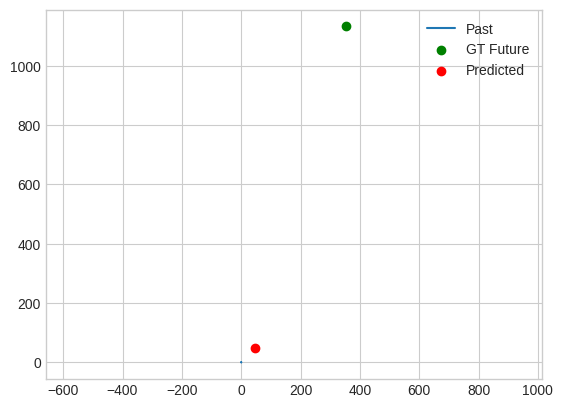

In [36]:
# =========================
# 16. Visualization
# =========================
past, future = dataset[0]
past = past.unsqueeze(0).to(device)

pred = model(past).cpu().detach().numpy()[0]

plt.plot(past[0,:,0].cpu(), past[0,:,1].cpu(), label="Past")
plt.scatter(future[-1,0], future[-1,1], c="green", label="GT Future")
plt.scatter(pred[0], pred[1], c="red", label="Predicted")
plt.legend()
plt.axis("equal")
plt.show()